In [1]:
%%time 

import time 
import torch
from PIL import Image
from torchvision import transforms
from pathlib import Path
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np


CPU times: total: 4 s
Wall time: 4.24 s


In [2]:
%%time 

# --- 1. DÉFINITION DE L'ARCHITECTURE (Obligatoire pour charger les poids) ---
class DinoClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(DinoClassifier, self).__init__()
        # On charge le même backbone que pendant l'entraînement
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        self.classifier = nn.Linear(384, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

CPU times: total: 0 ns
Wall time: 0 ns


In [3]:
%%time 

def predict_image(image_path, model_path, class_names):
    # 1. Définir les mêmes transformations qu'à l'entraînement
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # 2. Charger l'image
    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0) # Ajouter une dimension de batch (1, 3, 224, 224)

    # 3. Charger le modèle
    device = torch.device("cpu")
    model = DinoClassifier(num_classes=len(class_names)) # Utilise la classe définie plus haut
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # 4. Prédire
    with torch.no_grad():
        outputs = model(img_t.to(device))
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)

    # 5. Afficher le résultat
    label = class_names[predicted_idx.item()]
    print(f"Prédiction : {label} ({confidence.item()*100:.2f}%)")

project_root = Path.cwd()
print("project_root : " + str(project_root))

model_path = str(project_root) + '/best_dino_finetuned.pth'

project_root : c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\DINOv2
CPU times: total: 0 ns
Wall time: 998 μs


In [4]:
%%time 

def predict_with_details(image_path, model_path, class_names):
    device = torch.device("cpu")
    
    # 1. Préparation du modèle
    model = DinoClassifier(num_classes=len(class_names))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    # 2. Préparation de l'image
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    # 3. Calcul des probabilités
    with torch.no_grad():
        outputs = model(image_tensor)
        # Softmax transforme les scores en probabilités (0 à 1)
        probabilities = F.softmax(outputs, dim=1)[0]
        predicted_class_idx = np.argmax(probabilities)
        confidence = probabilities[predicted_class_idx]

    # 4. Affichage des détails
    print(f"--- Détails des prédictions pour : {image_path} ---")
    
    # On trie les résultats par probabilité décroissante
    results = []
    for i, prob in enumerate(probabilities):
        results.append((class_names[i], prob.item()))
    
    results.sort(key=lambda x: x[1], reverse=True)

    for name, score in results:
        # Affichage avec une petite barre visuelle
        bar = "#" * int(score * 20)
        print(f"{name:<15} : {score*100:>6.2f}% {bar}")
    
    # Top 3 prédictions
    probs_np = probabilities.cpu().numpy()
    top3_idx = np.argsort(probs_np)[::-1]

    return {
        'predicted_class': class_names[predicted_class_idx],
        'confidence': confidence,
        'top3': [(class_names[i], probabilities[i]) for i in top3_idx],
        'all_probabilities': probabilities
    }



CPU times: total: 0 ns
Wall time: 0 ns


In [5]:
%%time 

# --- UTILISATION ---

sample_image_path = "C:/Users/huber_otpq54a/OneDrive/Documents/Formation/IA/Developpement/Projets/Deep_Learning/Test/accident-de-voiture.webp"

class_names = ['00-normal', '01-minor', '02-moderate', '03-severe']
result = predict_with_details(sample_image_path, model_path, class_names)

Using cache found in C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\huber_otpq54a/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


--- Détails des prédictions pour : C:/Users/huber_otpq54a/OneDrive/Documents/Formation/IA/Developpement/Projets/Deep_Learning/Test/accident-de-voiture.webp ---
02-moderate     :  68.07% #############
03-severe       :  26.32% #####
01-minor        :   5.60% #
00-normal       :   0.00% 
CPU times: total: 2.62 s
Wall time: 428 ms


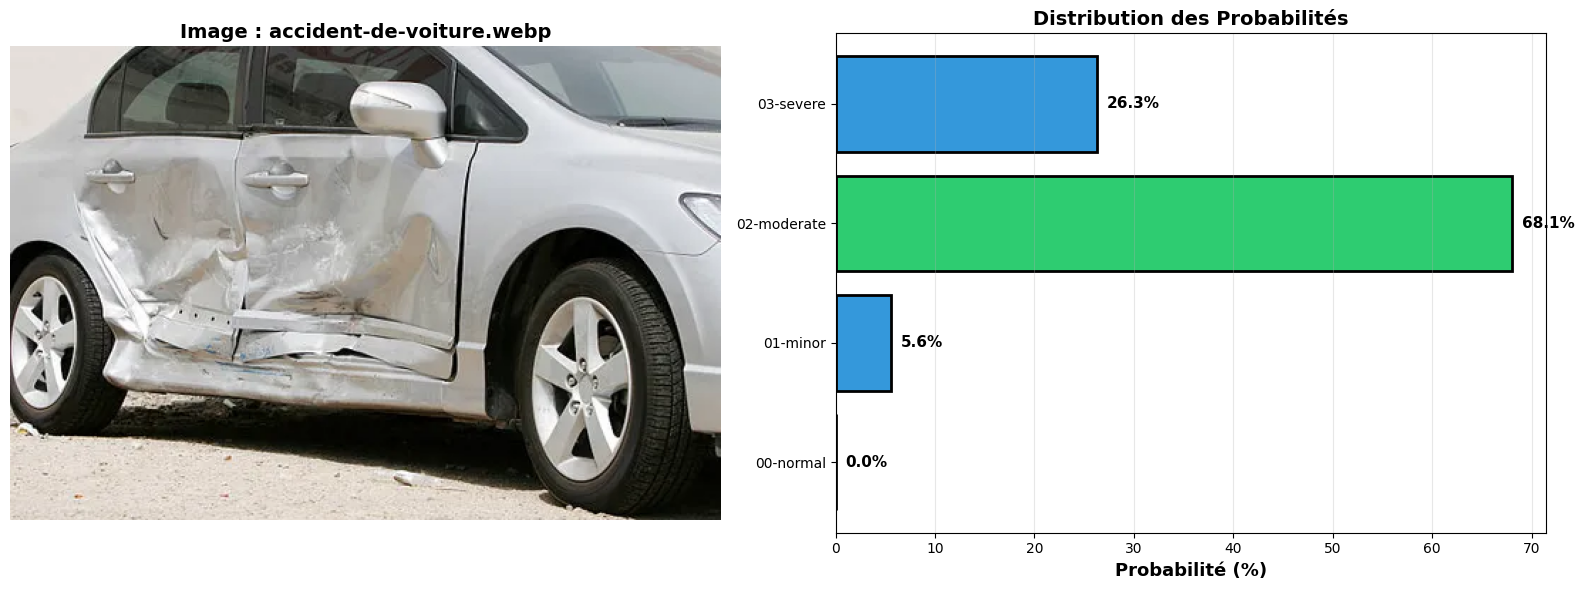


🔍 Analyse de la prédiction :
  - Classe prédite : 02-moderate
  - Confiance      : 68.07%

  - Top prédictions :
    1. 02-moderate     : 68.07%
    2. 03-severe       : 26.32%
    3. 01-minor        : 5.60%
    4. 00-normal       : 0.00%
CPU times: total: 1.52 s
Wall time: 197 ms


In [6]:
%%time 

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Image
img = plt.imread(sample_image_path)
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f"Image : {str(Path(sample_image_path).name)}", fontsize=14, fontweight='bold')

# Probabilités
probs = result['all_probabilities'] * 100
colors = ['#2ecc71' if i == np.argmax(probs) else '#3498db' for i in range(len(probs))]

bars = axes[1].barh(class_names, probs, color=colors, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Probabilité (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Distribution des Probabilités', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Ajouter les valeurs
for bar, prob in zip(bars, probs):
    width = bar.get_width()
    axes[1].text(width + 1, bar.get_y() + bar.get_height()/2.,
                f'{prob:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🔍 Analyse de la prédiction :")
print(f"  - Classe prédite : {result['predicted_class']}")
print(f"  - Confiance      : {result['confidence']*100:.2f}%")
print(f"\n  - Top prédictions :")
for i, (cls, prob) in enumerate(result['top3'], 1):
    print(f"    {i}. {cls:15s} : {prob*100:.2f}%")